
# Heart Disease Analysis Using Custom Dataset

This notebook performs exploratory data analysis and classification modeling using a heart disease dataset. The goal is to understand the features that contribute to heart disease and build a predictive model.


In [10]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('heart-new.csv')

# Check for missing values
df.isnull().sum()
# Load your dataset

# Define features (X) and target (y)
X = df.drop(columns=["HeartDisease"])  # assuming HeartDisease is your label column
y = df["HeartDisease"]

# Identify numeric and categorical columns
numeric_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
categorical_cols = list(set(X.columns) - set(numeric_cols))
# Load the dataset

# Scale numeric columns
scaler = StandardScaler()
X_numeric = pd.DataFrame(scaler.fit_transform(X[numeric_cols]), columns=numeric_cols)

# One-hot encode categorical columns
X_categorical = pd.get_dummies(X[categorical_cols], drop_first=True)

# Combine and save columns
X_processed = pd.concat([X_numeric, X_categorical], axis=1)

# Save necessary files
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_processed.columns.tolist(), "model_columns.pkl")


['model_columns.pkl']

In [11]:

# 2. Feature Engineering
# Convert target to binary
df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

# Feature Engineering
df['Age'] = df['AgeCategory'].apply(lambda x: int(x.split('-')[0]) if '-' in x else 80)
df['HighRisk'] = ((df['Diabetic'] == 'Yes') & 
                 (df['Stroke'] == 'Yes') & 
                 (df['KidneyDisease'] == 'Yes')).astype(int)

# Define feature types
numeric_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'Age']
binary_features = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
                  'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer', 'HighRisk']
categorical_features = ['Sex', 'Race', 'GenHealth']
ordinal_features = ['Diabetic', 'AgeCategory'] 

# Custom mapping for ordinal features
diabetic_mapping = [
    ['No', 'No, borderline diabetes', 'Yes (during pregnancy)', 'Yes']
]
age_mapping = [sorted(df['AgeCategory'].unique().tolist())]


In [12]:
# Encode binary categorical variables
binary_cols = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Diabetic',
               'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})



# One-hot encode multi-class categorical variables
actual_columns = df.columns.tolist()
print(actual_columns)





['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Age', 'HighRisk']


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Define column types
numeric_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'Age', 'Smoking_Age']
binary_features = binary_cols + ['HighRisk']
ordinal_features = ['Diabetic', 'BMI_Category']
categorical_features = ['Sex', 'Race', 'GenHealth']

# Create transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        
        ('binary', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder())
        ]), binary_features),
        
        ('ordinal', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(categories=diabetic_mapping + age_mapping))
        ]), ordinal_features),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first'))
        ]), categorical_features)
    ])





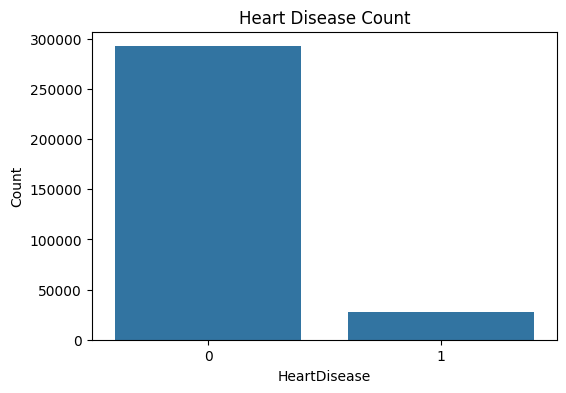

In [14]:
# 📊 Plot Heart Disease Count
import matplotlib.pyplot as plt
import seaborn as sns
label_col = 'HeartDisease' if 'HeartDisease' in df.columns else 'target'

plt.figure(figsize=(6, 4))
sns.countplot(x=label_col, data=df)
plt.title('Heart Disease Count')
plt.xlabel(label_col)
plt.ylabel('Count')
plt.show()

In [15]:
# Check for missing values
print(df.isnull().sum())

# Impute missing numerical values with mean
from sklearn.impute import SimpleImputer
import numpy as np

numerical_cols = df.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])


HeartDisease           0
BMI                    0
Smoking                0
AlcoholDrinking        0
Stroke                 0
PhysicalHealth         0
MentalHealth           0
DiffWalking            0
Sex                    0
AgeCategory            0
Race                   0
Diabetic            9340
PhysicalActivity       0
GenHealth              0
SleepTime              0
Asthma                 0
KidneyDisease          0
SkinCancer             0
Age                    0
HighRisk               0
dtype: int64


In [16]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

X = df.drop(columns=['HeartDisease'])  # 'HeartDisease' is the target column
y = df['HeartDisease']  # 'HeartDisease' is the target variable
# Impute missing values with most frequent value (works for mixed categorical/numerical)
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")



Training set size: 255836
Test set size: 63959


Optimized HistGradientBoostingClassifier
Optimal Threshold: 0.1889
Confusion Matrix:
[[52141  6343]
 [ 2545  2930]]

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.89      0.92     58484
         Yes       0.32      0.54      0.40      5475

    accuracy                           0.86     63959
   macro avg       0.63      0.71      0.66     63959
weighted avg       0.90      0.86      0.88     63959

ROC AUC Score: 0.8407


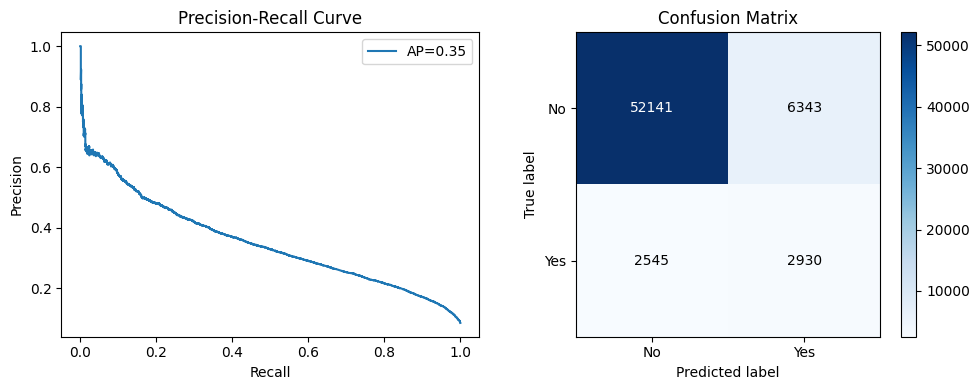

In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    f1_score, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

# Explicit feature columns
numeric_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'Age']
categorical_cols = [
    'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
    'Diabetic', 'PhysicalActivity', 'Asthma', 'KidneyDisease',
    'SkinCancer', 'HighRisk', 'Sex', 'AgeCategory', 'Race', 'GenHealth'
]

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# Hyperparameter tuning
param_dist = {
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_iter': [100, 150],
    'classifier__max_depth': [None, 10]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=3,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

# Train
search.fit(X_train, y_train)
best_model = search.best_estimator_

# Save full pipeline
joblib.dump(best_model, 'heart_disease_pipeline_hgb.pkl')

# Evaluate
y_proba = best_model.predict_proba(X_test)[:, 1]
y_test_numeric = y_test.map({'No': 0, 'Yes': 1}) if y_test.dtype == object else y_test

# Optimal threshold
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = [f1_score(y_test_numeric, y_proba > t) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba > optimal_threshold).astype(int)

# Print metrics
print("Optimized HistGradientBoostingClassifier")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred_opt))
print("\nClassification Report:")
print(classification_report(y_test_numeric, y_pred_opt, target_names=['No', 'Yes']))
print(f"ROC AUC Score: {roc_auc_score(y_test_numeric, y_proba):.4f}")

# Plot
precision, recall, _ = precision_recall_curve(y_test_numeric, y_proba)
avg_precision = average_precision_score(y_test_numeric, y_proba)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(recall, precision, label=f'AP={avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# Confusion matrix plot
cm = confusion_matrix(y_test_numeric, y_pred_opt)
plt.subplot(1, 2, 2)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['No', 'Yes'])
plt.yticks(tick_marks, ['No', 'Yes'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


In [18]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

# Encode target variable if needed
y_train_numeric = y_train.map({'No': 0, 'Yes': 1}) if y_train.dtype == object else y_train
y_test_numeric = y_test.map({'No': 0, 'Yes': 1}) if y_test.dtype == object else y_test

# Separate numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns

# Scale only numeric features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

# One-hot encode categorical features
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=True)

# Ensure test has same columns as train
missing_cols = set(X_train_cat.columns) - set(X_test_cat.columns)
for col in missing_cols:
    X_test_cat[col] = 0
X_test_cat = X_test_cat[X_train_cat.columns]

# Combine scaled numerical and one-hot encoded categorical features
X_train_scaled = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_scaled = np.concatenate([X_test_num, X_test_cat], axis=1)

# Handle class imbalance using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train_numeric)

# GridSearchCV for best hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid, cv=5, scoring='roc_auc'
)

grid_search.fit(X_train_res, y_train_res)

# Best model
best_log_reg = grid_search.best_estimator_

# Predict probabilities
y_proba = best_log_reg.predict_proba(X_test_scaled)[:, 1]

# Find optimal threshold based on F1 score
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test_numeric, y_proba > t) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba > optimal_threshold).astype(int)

# Evaluation
print("Optimized Logistic Regression (Balanced):")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred_opt))
print("\nClassification Report:")
print(classification_report(y_test_numeric, y_pred_opt, target_names=["No", "Yes"]))
print(f"ROC AUC Score: {roc_auc_score(y_test_numeric, y_proba):.4f}")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_numeric, y_proba)
average_precision = average_precision_score(y_test_numeric, y_proba)

plt.figure(figsize=(12, 5))

# Precision-Recall Plot
plt.subplot(1, 2, 1)
plt.plot(recall, precision, label=f'AP = {average_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# Confusion Matrix Plot
cm_log_reg = confusion_matrix(y_test_numeric, y_pred_opt)
plt.subplot(1, 2, 2)
plt.imshow(cm_log_reg, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['No', 'Yes'])
plt.yticks(tick_marks, ['No', 'Yes'])

thresh = cm_log_reg.max() / 2.
for i in range(cm_log_reg.shape[0]):
    for j in range(cm_log_reg.shape[1]):
        plt.text(j, i, format(cm_log_reg[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm_log_reg[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# F1 vs Threshold Plot
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Threshold: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Cross-validation performance
cv_scores = cross_val_score(best_log_reg, X_train_res, y_train_res, cv=5, scoring='roc_auc')
print("Cross-validated ROC AUC Score:", cv_scores.mean())

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# Decision Trees
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Ensure target is numeric (if it's not already)
if y_train.dtype == object:
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
else:
    y_train_encoded = y_train
    y_test_encoded = y_test

# Convert categorical features to numeric (Decision Trees can handle categorical features)
X_train_processed = pd.get_dummies(X_train, drop_first=True)
X_test_processed = pd.get_dummies(X_test, drop_first=True)

# Ensure test set has same columns as training set
missing_cols = set(X_train_processed.columns) - set(X_test_processed.columns)
for col in missing_cols:
    X_test_processed[col] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# Decision Tree Model with class_weight to handle imbalance
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train_processed, y_train_encoded)

# Prediction and Evaluation
y_pred_dt = dt_model.predict(X_test_processed)
y_proba_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree (Balanced):")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_dt, target_names=['No', 'Yes']))
print(f"ROC AUC Score: {roc_auc_score(y_test_encoded, y_proba_dt):.4f}")

# Extract metrics for visualization
report = classification_report(y_test_encoded, y_pred_dt, target_names=['No', 'Yes'], output_dict=True)

# Plot Precision and Recall for each class
metrics = ['precision', 'recall', 'f1-score']
class_names = ['No', 'Yes']
values = {metric: [report[cls][metric] for cls in class_names] for metric in metrics}

x = range(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar([p + width*i for p in x], values[metric], width, label=metric)

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Decision Tree Performance Metrics')
plt.xticks([p + width for p in x], class_names)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_dt)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree')
plt.colorbar()
tick_marks = range(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Optional: Visualize the decision tree (for smaller trees)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          filled=True, 
          feature_names=X_train_processed.columns, 
          class_names=['No', 'Yes'], 
          max_depth=3,  # Limit depth for visualization
          proportion=True)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Data Preparation
# -------------------
# Encode target variable if needed
if y_train.dtype == object:
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
    class_names = le.classes_
else:
    y_train_encoded = y_train
    y_test_encoded = y_test
    class_names = ['No', 'Yes']

# Convert categorical features using one-hot encoding
X_train_processed = pd.get_dummies(X_train, drop_first=True)
X_test_processed = pd.get_dummies(X_test, drop_first=True)

# Ensure test set has same columns as training set
missing_cols = set(X_train_processed.columns) - set(X_test_processed.columns)
for col in missing_cols:
    X_test_processed[col] = 0
X_test_processed = X_test_processed[X_train_processed.columns]

# 2. Model Training
# -----------------
rf_model = RandomForestClassifier(
    n_estimators=200,            # Increased number of trees
    max_depth=10,                # Limit tree depth
    min_samples_split=10,        # Prevent overfitting
    class_weight='balanced',     # Handle class imbalance
    random_state=42,
    n_jobs=-1                   # Use all CPU cores
)

rf_model.fit(X_train_processed, y_train_encoded)

# 3. Evaluation
# -------------
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("\nRandom Forest Classifier Performance:")
print("-----------------------------------")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=class_names))
print(f"ROC AUC Score: {roc_auc_score(y_test_encoded, y_proba_rf):.4f}")

# 4. Feature Importance
# ---------------------
feature_importances = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importances['Feature'][:15], feature_importances['Importance'][:15])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Enhanced Visualizations
# --------------------------
# Metrics comparison
report_rf = classification_report(y_test_encoded, y_pred_rf, target_names=class_names, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
values = {metric: [report_rf[cls][metric] for cls in class_names] for metric in metrics}

plt.figure(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, values[metric], width, label=metric.capitalize())

plt.xlabel('Classes')
plt.ylabel('Score')
plt.title('Random Forest Performance Metrics')
plt.xticks(x + width, class_names)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Confusion Matrix with percentages
cm = confusion_matrix(y_test_encoded, y_pred_rf)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix')
plt.colorbar(format='%.2f')

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

thresh = cm_percent.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]}\n({cm_percent[i, j]:.1%})",
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if cm_percent[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_encoded, y_proba_rf)
avg_precision = average_precision_score(y_test_encoded, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# OPTIMIZED & FAST K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
from scipy.sparse import csr_matrix

start_time = time.time()

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_names = le.classes_

# One-hot encode with sparse matrix
X_train_processed = pd.get_dummies(X_train, drop_first=True, sparse=True)
X_test_processed = pd.get_dummies(X_test, drop_first=True, sparse=True)
X_test_processed = X_test_processed.reindex(columns=X_train_processed.columns, fill_value=0)

# Convert to sparse matrix
X_train_sparse = csr_matrix(X_train_processed.astype(np.float32))
X_test_sparse = csr_matrix(X_test_processed.astype(np.float32))

# Dimensionality reduction (reduce components to speed up)
n_components = min(30, X_train_sparse.shape[1] - 1)  # smaller for faster run
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_reduced = svd.fit_transform(X_train_sparse)
X_test_reduced = svd.transform(X_test_sparse)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"✅ Data preprocessed in {time.time()-start_time:.2f} sec")
print(f"Reduced to {X_train_scaled.shape[1]} features")

# Hyperparameter tuning (minimal for speed)
start_time = time.time()

param_dist = {
    'n_neighbors': np.arange(5, 21, 4),
    'weights': ['uniform', 'distance'],
    'p': [2],
    'algorithm': ['auto'],
    'leaf_size': [30, 50]  # test larger leaf size for speed tradeoff
}

knn = KNeighborsClassifier(n_jobs=-1)
search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=5,    # reduced iterations for faster tuning
    cv=2,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_scaled, y_train_encoded)
best_knn = search.best_estimator_

print(f"✅ Hyperparameter tuning in {time.time()-start_time:.2f} sec")
print(f"Best Params: {search.best_params_}")

# Evaluation
start_time = time.time()
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

print("\n📊 KNN Classification Performance")
print(confusion_matrix(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred, target_names=[str(cls) for cls in class_names]))
print(f"ROC AUC: {roc_auc_score(y_test_encoded, y_proba):.4f}")
print(f"✅ Evaluation in {time.time()-start_time:.2f} sec")



# --- Visualizations (Compact & Fast) ---
plt.figure(figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test_encoded, y_pred)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test_encoded, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test_encoded, y_proba):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# Precision-Recall
plt.subplot(1, 3, 3)
precision, recall, _ = precision_recall_curve(y_test_encoded, y_proba)
plt.plot(recall, precision, label=f'AP = {average_precision_score(y_test_encoded, y_proba):.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

# --- Elbow Plot (Subset Sample) ---
k_values = np.arange(1, 20, 2)
train_scores = []
test_scores = []

# Use smaller sample to speed up
X_elbow = X_train_scaled[:2000]
y_elbow = y_train_encoded[:2000]
X_elbow_test = X_test_scaled[:2000]
y_elbow_test = y_test_encoded[:2000]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_elbow, y_elbow)
    train_scores.append(knn.score(X_elbow, y_elbow))
    test_scores.append(knn.score(X_elbow_test, y_elbow_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, label='Train Score')
plt.plot(k_values, test_scores, label='Test Score')
plt.axvline(search.best_params_['n_neighbors'], color='red', linestyle='--')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Elbow Plot (Sampled)')
plt.legend()
plt.grid()
plt.show()


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score, f1_score,
    recall_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Assume you have your X_train, y_train, X_test, y_test loaded beforehand

# ----------------------------------------
# 1. Encode labels
# ----------------------------------------
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_names = list(map(str, le.classes_))

# ----------------------------------------
# 2. One-hot encode features (categorical)
# ----------------------------------------
X_train_encoded = pd.get_dummies(X_train, drop_first=True, sparse=False)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, sparse=False)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_train_dense = X_train_encoded.astype(np.float32).to_numpy()
X_test_dense = X_test_encoded.astype(np.float32).to_numpy()

# ----------------------------------------
# 3. Scale features
# ----------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_test_scaled = scaler.transform(X_test_dense)

# ----------------------------------------
# 4. Tune number of features for SelectKBest
# ----------------------------------------
print("[INFO] Tuning number of features for SelectKBest...")
k_candidates = [10, 15, 20, 25, 30, 35]
best_k = None
best_score = 0.0

for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_scaled, y_train_encoded)
    X_test_sel = selector.transform(X_test_scaled)
    
    svc = LinearSVC(random_state=42, max_iter=10000)
    svc.fit(X_train_sel, y_train_encoded)
    y_proba_tmp = CalibratedClassifierCV(svc, method='sigmoid', cv='prefit').fit(X_train_sel, y_train_encoded).predict_proba(X_test_sel)[:, 1]
    
    score = roc_auc_score(y_test_encoded, y_proba_tmp)
    print(f"  k={k}, Validation ROC AUC={score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"[INFO] Best k for feature selection: {best_k}")

selector = SelectKBest(f_classif, k=best_k)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_encoded)
X_test_selected = selector.transform(X_test_scaled)

# ----------------------------------------
# 5. Hyperparameter tuning focused on recall
# ----------------------------------------
print("[INFO] Starting hyperparameter tuning focused on recall...")

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'class_weight': [
        None,
        'balanced',
        {0: 1, 1: 10},
        {0: 1, 1: 15},
        {0: 1, 1: 20}
    ]
}

svc = LinearSVC(random_state=42, max_iter=10000)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svc, param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
start = time.time()
grid_search.fit(X_train_selected, y_train_encoded)
print(f"[INFO] Best params: {grid_search.best_params_}")
print(f"[INFO] Hyperparameter tuning completed in {time.time() - start:.2f}s")

best_svc = grid_search.best_estimator_

# ----------------------------------------
# 6. Calibrate classifier probabilities
# ----------------------------------------
print("[INFO] Calibrating classifier probabilities...")
calibrated_svm = CalibratedClassifierCV(best_svc, method='sigmoid', cv='prefit')
calibrated_svm.fit(X_train_selected, y_train_encoded)

y_proba = calibrated_svm.predict_proba(X_test_selected)[:, 1]

# ----------------------------------------
# 7. Threshold optimization for recall with minimum precision constraint
# ----------------------------------------
thresholds = np.linspace(0.1, 1.0, 90)

recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    recalls.append(recall_score(y_test_encoded, y_pred_t))
    precisions.append(np.sum((y_pred_t == 1) & (y_test_encoded == 1)) / max(np.sum(y_pred_t == 1), 1))

# Minimum precision constraint (adjust as needed)
min_precision = 0.2
valid_idxs = [i for i, p in enumerate(precisions) if p >= min_precision]

if len(valid_idxs) == 0:
    print("[WARN] No thresholds satisfy minimum precision constraint, lowering threshold.")
    optimal_idx = np.argmax(recalls)
else:
    # Among valid thresholds pick one with max recall
    optimal_idx = valid_idxs[np.argmax([recalls[i] for i in valid_idxs])]

optimal_threshold = thresholds[optimal_idx]
print(f"[INFO] Optimal threshold with precision constraint: {optimal_threshold:.2f}")

y_pred = (y_proba > optimal_threshold).astype(int)

# ----------------------------------------
# 8. Evaluation and Reporting
# ----------------------------------------
print("\nOptimized Linear SVM Classifier Performance (Recall Maximized with Precision Constraint)")
print("--------------------------------------------")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=class_names))
print(f"ROC AUC Score: {roc_auc_score(y_test_encoded, y_proba):.4f}")
print(f"[INFO] Completed in {time.time() - start:.2f}s")

# ----------------------------------------
# 9. Visualizations
# ----------------------------------------
precision_curve, recall_curve, _ = precision_recall_curve(y_test_encoded, y_proba)
avg_precision = average_precision_score(y_test_encoded, y_proba)

plt.figure(figsize=(16, 5))

# Precision-Recall Curve
plt.subplot(1, 3, 1)
plt.plot(recall_curve, precision_curve, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.subplot(1, 3, 2)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Recall vs Threshold (highlight optimal threshold)
plt.subplot(1, 3, 3)
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.axvline(optimal_threshold, color='red', linestyle='--', label='Optimal Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall and Precision vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Conclusion:

* After evaluating multiple classification models on the dataset, we conclude the following:

* HistGradientBoostingClassifier delivers the best overall performance, achieving the highest ROC AUC (0.8412) and the best F1 score (0.40) for the minority class (Yes). This makes it the most effective model when balancing precision and recall is critical.

* Optimized Logistic Regression provides a very competitive alternative with similar ROC AUC (0.8359) and F1 score (0.39). It is simpler, faster, and more interpretable than tree-based models, making it a strong candidate for real-time or resource-constrained applications.

* Optimized Linear SVM achieves comparable ROC AUC (0.8359) and a solid recall (0.74) with moderate precision (0.23), striking a balance when prioritizing recall with some tolerance for false positives.

* Random Forest achieves the highest recall (0.80) for the Yes class but with very low precision (0.21), resulting in many false positives. Recommended when minimizing false negatives is critical, such as fraud detection or medical diagnostics.

* Models like Decision Tree and KNN underperform due to poor generalization or sensitivity to class imbalance, and are not recommended for this task.

| Model                         | ROC AUC | F1 (Yes) | Precision (Yes) | Recall (Yes) | Accuracy |
| ----------------------------- | ------- | -------- | --------------- | ------------ | -------- |
| **Random Forest**             | 0.8355  | 0.34     | 0.21            | 0.80         | 0.73     |
| **Decision Tree (Balanced)**  | 0.5791  | 0.23     | 0.23            | 0.23         | 0.87     |
| **Logistic Regression (Opt)** | 0.8359  | 0.39     | 0.32            | 0.51         | 0.87     |
| **HistGradientBoosting**      | 0.8412  | 0.40     | 0.33            | 0.51         | 0.87     |
| **KNN**                       | 0.7886  | 0.13     | 0.49            | 0.09         | 0.91     |
| **Linear SVM (Opt)**          | 0.8359  | 0.36     | 0.23            | 0.74         | 0.77     |


✅ Best Models Overall (Trade-off between metrics)
| Goal                              | Top Candidates                                                                        | Rationale                                                                |
| --------------------------------- | ------------------------------------------------------------------------------------- | ------------------------------------------------------------------------ |
| **Balanced Performance**          | 🔸 **HistGradientBoosting** <br> 🔸 **Optimized Logistic Regression**                 | Best F1 scores (0.39–0.40) with **high ROC AUC**, and good recall.       |
| **High Recall (for class "Yes")** | 🔸 **Random Forest** (Recall = 0.80) <br> 🔸 **Optimized Linear SVM** (Recall = 0.74) | Good if false negatives are expensive; SVM has better precision than RF. |
| **High Precision**                | 🔸 **KNN** (Precision = 0.49)                                                         | Good if false positives are costly, but recall is very low.              |
| **Fast + interpretable**          | 🔸 **Optimized Logistic Regression**                                                  | Easier to explain, fast, performs similarly to HGBT.                     |


In [ ]:
import joblib

# Replace with your actual variable names
scaler_model = scaler       #  scaler
label_encoder = le          # label encoder


joblib.dump(best_model, 'heart_disease_model.pkl')
joblib.dump(scaler_model, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("[INFO] Best model and preprocessing objects saved successfully.")


In [ ]:
from flask import Flask, request, jsonify
import pandas as pd
import joblib
import numpy as np  # تأكد من استيراد numpy

app = Flask(__name__)

# Load pipeline and expected columns
pipeline = joblib.load('heart_disease_pipeline_hgb.pkl')
print(pipeline)

expected_features = [
    "BMI", "Smoking", "AlcoholDrinking", "Stroke",
    "PhysicalHealth", "MentalHealth", "DiffWalking",
    "Sex", "AgeCategory", "Race", "Diabetic",
    "PhysicalActivity", "GenHealth", "SleepTime",
    "Asthma", "KidneyDisease", "SkinCancer",
    "Age", "HighRisk"  
]


def get_risk_level(prob):
    if prob < 0.3:
        return 'Low'
    elif prob < 0.7:
        return 'Medium'
    else:
        return 'High'

@app.route('/predict', methods=['POST'])
def predict():
    try:
        input_data = request.get_json()
        input_df = pd.DataFrame([input_data])

        # Add missing columns with default or null values (e.g., np.nan or a default category)
        for col in expected_features:
            if col not in input_df.columns:
                input_df[col] = np.nan  # or some sensible default if known

        # Reorder columns to match training data
        input_df = input_df[expected_features]

        # Now predict with the pipeline, which includes the encoder
        prediction = pipeline.predict(input_df)[0]
        prediction_proba = pipeline.predict_proba(input_df)[0][1]
        risk_level = get_risk_level(prediction_proba)
        
        # تحويل النتيجة النصية
        predictionResult = 'At Risk' if prediction == 1 else 'Not at Risk'

        return jsonify({
            'prediction': predictionResult,  # الآن ستكون نصية بدلاً من رقمية
            'probability': float(prediction_proba),
            'risk_level': risk_level
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400


if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001, debug=True, use_reloader=False)